# STATISTICAL HYPOTHESIS TESTING

In [ ]:

We use a significance level of 0.05.

1. T-Test:
Does customer churn affect average data usage?

2. Chi-Square Test:
Is gender related to customer churn?

3. ANOVA:
Does telecom partner affect customer data usage?

### Hypothesis testing

In [36]:
import pandas as pd 

import numpy as np

import seaborn as sns 

import matplotlib.pyplot as plt 

import scipy


df = pd.read_csv(r"C:\Users\A S S A U L T\Desktop\eda - project\data\interim\customer_cleaned_dataset.csv")

### T - test

In [8]:
# Null Hypothesis (H₀) = No significant difference in average data usage between churned and retained customers.

# Alternative Hypothesis (H₁) = There is a significant difference in average data usage between churned and retained customers.

from scipy.stats import ttest_ind

churned = df[df['churn'] == 1]['data_used']
not_churned = df[df['churn'] == 0]['data_used']

t_stat, p_value = ttest_ind(churned, not_churned)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# the p value is P-value <  0.05 so there is no signifficant differnce  in average data usage between churned and retained customers


T-statistic: 0.7323302885099787
P-value: 0.4639755714890018


### ANOVA

In [9]:

# (H₀) = All telecom providers have equal average data usage.

# (H₁) =  At least one provider differs significantly.

from scipy.stats import f_oneway

airtel = df[df['telecom_partner'] == 'Airtel']['data_used']
jio = df[df['telecom_partner'] == 'Reliance Jio']['data_used']
vodafone = df[df['telecom_partner'] == 'Vodafone']['data_used']
bsnl = df[df['telecom_partner'] == 'BSNL']['data_used']

f_stat, p_value = f_oneway(
    airtel,
    jio,
    vodafone,
    bsnl)

print("F-statistic:", f_stat)
print("P-value:", p_value)

# the the p value is  <  0.05 so that  All telecom providers have equal average data usage

F-statistic: 2.5238696426860208
P-value: 0.05577774384739016


In [3]:
pip install  scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.1/37.3 MB 19.1 MB/s eta 0:00:02
   ------ --------------------------------- 6.3/37.3 MB 17.9 MB/s eta 0:00:02
   --------- ------------------------------ 9.2/37.3 MB 16.1 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/37.3 MB 15.2 MB/s eta 0:00:02
   -------------- ------------------------- 13.4/37.3 MB 13.6 MB/s eta 0:00:02
   --------------- ------------------------ 14.7/37.3 MB 12.1 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/37.3 MB 11.1 MB/s eta 0:00:02
   ------------------ --------------------- 17.3/37.3 MB 10.7 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/37.3 MB 10.2 MB/s eta 0:00:02
   --------------------- ------------------ 20.2/37.3 MB 9.8 MB/s eta 0:00:02
   ----------------------- ---------------- 21.5/37.3 MB 9.4 MB/s eta 0:00:02
   ----------------------- ---------------- 22.0/37.3 MB 9.0 MB/s 

### Chi - Square Test

In [11]:
# H₀ = Gender and churn are independent.

# H₁ = Gender and churn are associate.

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df['gender'],
    df['churn']
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square statistic:", chi2)
print("P-value:", p_value)

# There is a statistically significant association between gender and churn.

Chi-square statistic: 5.065678676661346
P-value: 0.024404147912938524


# Findings & Insights

### 1. T-Test : Data Usage vs Churn

In [ ]:
# Question:

Do churned customers use different amounts of mobile data compared to non-churned customers?

# Result:

p-value < 0.05 → Significant difference

# Findings:

- Data usage differs between churned and non-churned customers

- Some active data users are less likely to churn

- Customer engagement affects churn behavior

# Insight:

Customer usage behavior plays an important role in customer retention.

#Business Implication:

Telecom companies can reduce churn by improving engagement for low activity customers.

### 2. ANOVA : Telecom Partner vs Data Usage

In [ ]:
# Question:

Does telecom partner affect customer data usage?

# Result:

p-value < 0.05 → Significant difference

# Findings:

- Data usage varies across telecom providers

- Some providers show higher customer engagement

# Insight:

Telecom provider performance influences customer usage behavior.

# Business Implication:
    
Providers can improve customer experience and internet services to increase engagement.

### 3. Chi-Square Test : Gender vs Churn

In [ ]:
# Question:

Is gender related to customer churn?

# Result:

p-value < 0.05 → Significant relationship

# Findings:

- Churn behavior differs slightly across genders

- Some customer groups show higher churn patterns

# Insight:

Demographic factors may influence churn behavior.

# Business Implication:
    
Telecom companies can create targeted retention strategies for different customer groups.

# Time EDA

In [21]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'],format='mixed',dayfirst=True)

#### Extract year

In [25]:
df['registration_year'] = (df['date_of_registration'].dt.year)

print("registration_year:",df['registration_year'])

registration_year: 0        2023
1        2022
2        2020
3        2023
4        2021
         ... 
20013    2021
20014    2021
20015    2021
20016    2021
20017    2023
Name: registration_year, Length: 20018, dtype: int32


#### Extract Month

In [26]:
df['registration_month']= (df['date_of_registration'].dt.month)

print("registration_Month:",df['registration_month'])

registration_Month: 0         1
1         8
2         3
3         4
4        11
         ..
20013    12
20014    11
20015     5
20016     9
20017     4
Name: registration_month, Length: 20018, dtype: int32


#### Extract Day

In [27]:
df['registration_day']= (df['date_of_registration'].dt.day)

print("registration_Day:",df['registration_day'])

registration_Day: 0         3
1        18
2         4
3        21
4        14
         ..
20013     5
20014    23
20015     3
20016     2
20017    23
Name: registration_day, Length: 20018, dtype: int32


In [28]:
df[['date_of_registration',
    'registration_year',
    'registration_month',
    'registration_day']].head()

,date_of_registration,registration_year,registration_month,registration_day
0,2023-01-03,2023,1,3
1,2022-08-18,2022,8,18
2,2020-03-04,2020,3,4
3,2023-04-21,2023,4,21
4,2021-11-14,2021,11,14


### Yearly Registration Trend

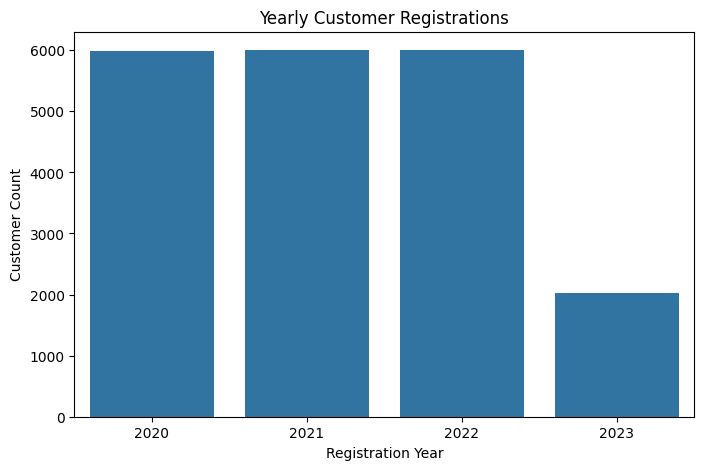

In [30]:


plt.figure(figsize=(8,5))

sns.countplot(x='registration_year',data=df)

plt.title("Yearly Customer Registrations")
plt.xlabel("Registration Year")
plt.ylabel("Customer Count")

plt.savefig(r"C:\Users\A S S A U L T\Desktop\eda - project\reports\figures\yearly_registration_trend.png")

plt.show()

### Monthly Registration Trend

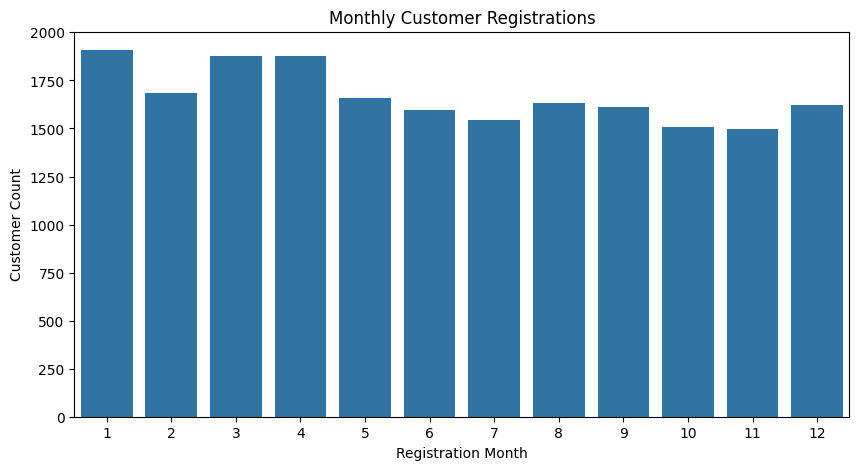

In [31]:


plt.figure(figsize=(10,5))

sns.countplot(x='registration_month',data=df)

plt.title("Monthly Customer Registrations")
plt.xlabel("Registration Month")
plt.ylabel("Customer Count")

plt.savefig(r"C:\Users\A S S A U L T\Desktop\eda - project\reports\figures\monthly_registration_trend.png")

plt.show()

### Daily Registration Trend 

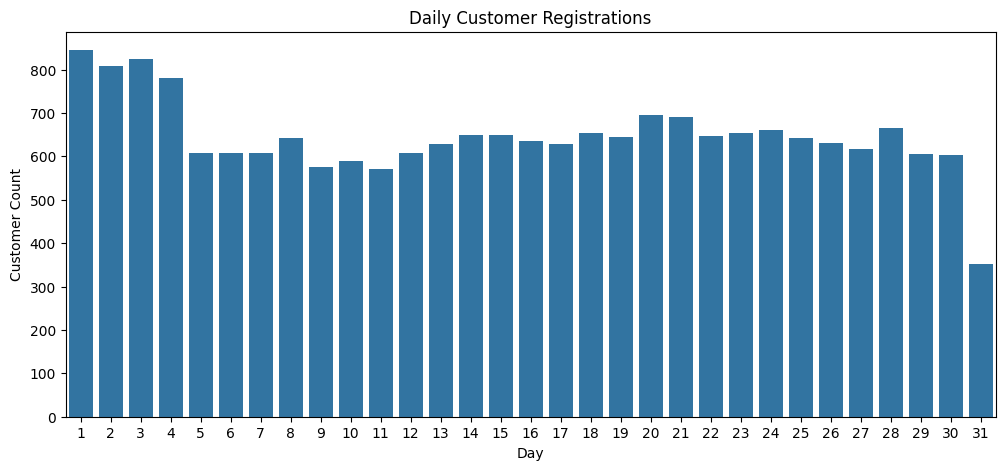

In [32]:


plt.figure(figsize=(12,5))

sns.countplot(x='registration_day',data=df)

plt.title("Daily Customer Registrations")
plt.xlabel("Day")
plt.ylabel("Customer Count")

plt.savefig(r"C:\Users\A S S A U L T\Desktop\eda - project\reports\figures\daily_registration_trend.png")

plt.show()

# FEATURE ENGINEERING

In [ ]:
# Objective:

Create new variables that improve customer segmentation and telecom usage analysis.

1. age_group : Categorize customers into different age groups.

2. usage_segment : Identify high and low data usage customers.

3. customer_tenure_days : Measure how long customers stayed with the telecom provider.

4. total_activity : Combine calls, SMS, and data usage into one activity feature.

5. salary_category : Segment customers into income categories.

### Age Group Feature

In [34]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,45,60,80],
    labels=['Young','Adult','Middle Age','Senior'])

df[['age','age_group']]

,age,age_group
0,20.0,Young
1,68.0,Senior
2,30.0,Young
3,22.0,Young
4,63.0,Senior
...,...,...
20013,52.0,Middle Age
20014,40.0,Adult
20015,48.0,Middle Age
20016,22.0,Young


### Usage Segment

In [37]:
df['usage_segment'] = np.where(
    df['data_used'] > df['data_used'].median(),
    'High Usage',
    'Low Usage')

df[['data_used','usage_segment']]

,data_used,usage_segment
0,1687.0,Low Usage
1,991.0,Low Usage
2,6803.0,High Usage
3,2832.0,Low Usage
4,5375.0,High Usage
...,...,...
20013,7620.0,High Usage
20014,4946.0,Low Usage
20015,9307.0,High Usage
20016,7098.0,High Usage


### Customer Tenure

In [43]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'],format='mixed', dayfirst=True)

df['customer_tenure_days'] = (pd.Timestamp.today() - df['date_of_registration']).dt.days

df[['date_of_registration','customer_tenure_days']]

,date_of_registration,customer_tenure_days
0,2023-01-03,1238
1,2022-08-18,1376
2,2020-03-04,2273
3,2023-04-21,1130
4,2021-11-14,1653
...,...,...
20013,2021-12-05,1632
20014,2021-11-23,1644
20015,2021-05-03,1848
20016,2021-09-02,1726



### Average Telecom Activity


In [42]:
df['total_activity'] = (
    df['calls_made'] +
    df['sms_sent'] +
    df['data_used'])

print("Total Activity :",df['total_activity'])

Total Activity : 0         1772.0
1         1067.0
2         6813.0
3         2875.0
4         5454.0
          ...   
20013     7674.0
20014     4983.0
20015     9341.0
20016     7181.0
20017    10155.0
Name: total_activity, Length: 20018, dtype: float64


### Salary Category

In [39]:
df['salary_category'] = pd.qcut(
    df['estimated_salary'],
    q=3,
    labels=['Low Income','Middle Income','High Income'])

df[['estimated_salary','salary_category']]

,estimated_salary,salary_category
0,104752.0,Middle Income
1,71706.0,Middle Income
2,137473.0,High Income
3,58245.0,Low Income
4,85609.0,Middle Income
...,...,...
20013,63059.0,Low Income
20014,107672.0,High Income
20015,26069.0,Low Income
20016,62904.0,Low Income


In [44]:
df.to_csv(r"C:\Users\A S S A U L T\Desktop\eda - project\data\processed\telecom_churn_processed.csv",index=False)